In [ ]:
 ── CELL 1 ─────────────────────────────────────────────────────────
!pip install tensorflow kaggle split-folders seaborn pillow -q

import os, json, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                              ReduceLROnPlateau)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as kimage
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight as cw_util
from PIL import Image
import splitfolders

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow {tf.__version__}")
print(f"GPU: {gpus}")
if not gpus:
    print("⚠️  NO GPU! Go to Runtime → Change runtime type → T4 GPU NOW")

TensorFlow 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── CELL 2 ─────────────────────────────────────────────────────────
IMG_SIZE    = 192
BATCH_SIZE  = 24
SEED        = 42
EPOCHS_FT   = 10    # Phase 1: frozen base
EPOCHS_FINE = 15    # Phase 2: fine-tune
LR_FT       = 1e-3
LR_FINE     = 5e-5
UNFREEZE_N  = 40    # unfreeze last 40 layers of EfficientNetB3
THRESHOLD   = 0.60  # confidence below this = "not a plant leaf"

# Paths
DATA_DIR = "/content/plantvillage/plantvillage dataset/color"
OUT_DIR   = '/content/split_data'
TRAIN_DIR = os.path.join(OUT_DIR, 'train')
VAL_DIR   = os.path.join(OUT_DIR, 'val')
TEST_DIR  = os.path.join(OUT_DIR, 'test')

print("Config ready ✓")
print(f"IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE} | LR_FT={LR_FT} | LR_FINE={LR_FINE}")

Config ready ✓
IMG_SIZE=192 | BATCH=24 | LR_FT=0.001 | LR_FINE=5e-05


In [ ]:
# ── CELL 3 ─────────────────────────────────────────────────────────
# NEW DATASET: abdallahalidev/plantvillage-dataset
# Has 38 classes, 14 plant types, 54,305 images
# Much better than emmarex which only had tomato+pepper

from google.colab import files

# Upload kaggle.json
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download dataset (~1.5 GB — takes 3-5 mins on Colab)
!kaggle datasets download -d abdallahalidev/plantvillage-dataset \
    -p /content/plantvillage --unzip -q

# Check what got downloaded
!ls /content/plantvillage/

classes = os.listdir(DATA_DIR)
print(f"\n✅ Download complete!")
print(f"Total classes found: {len(classes)}")
print("\nAll classes:")
for i, c in enumerate(sorted(classes)):
    print(f"  {i+1:2d}. {c}")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
'plantvillage dataset'

✅ Download complete!
Total classes found: 38

All classes:
   1. Apple___Apple_scab
   2. Apple___Black_rot
   3. Apple___Cedar_apple_rust
   4. Apple___healthy
   5. Blueberry___healthy
   6. Cherry_(including_sour)___Powdery_mildew
   7. Cherry_(including_sour)___healthy
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   9. Corn_(maize)___Common_rust_
  10. Corn_(maize)___Northern_Leaf_Blight
  11. Corn_(maize)___healthy
  12. Grape___Black_rot
  13. Grape___Esca_(Black_Measles)
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  15. Grape___healthy
  16. Orange___Haunglongbing_(Citrus_greening)
  17. Peach___Bacterial_spot
  18. Peach___healthy
  19. Pepper,_bell___Bacterial_spot
  20. Pepper,_bell___healthy
  21. Potato___Early_blight
  22. Potato___Late_blight
  23. Potato___healthy
  24. Raspberry___healthy


Copying files: 54305 files [00:12, 4204.42 files/s]


Split done ✓
Number of classes: 38

Smallest class : Potato___healthy (106 images)
Largest class  : Orange___Haunglongbing_(Citrus_greening) (3854 images)
Imbalance ratio: 36.4x


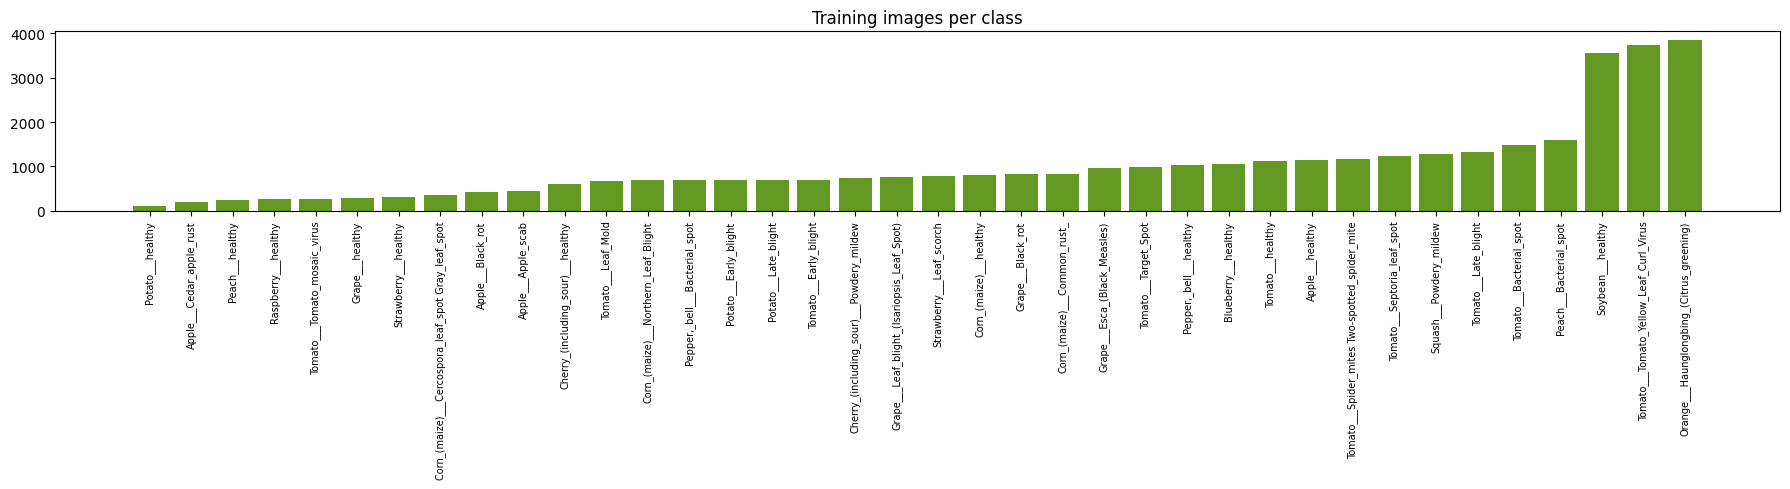

In [ ]:
# ── CELL 4 ─────────────────────────────────────────────────────────
if not os.path.exists(OUT_DIR):
    splitfolders.ratio(
        DATA_DIR, output=OUT_DIR,
        seed=SEED, ratio=(.70, .15, .15)
    )
    print("Split done ✓")
else:
    print("Split already exists ✓")

NUM_CLASSES = len(os.listdir(TRAIN_DIR))
print(f"Number of classes: {NUM_CLASSES}")

# Check class distribution
counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c)))
          for c in os.listdir(TRAIN_DIR)}
counts = dict(sorted(counts.items(), key=lambda x: x[1]))

print(f"\nSmallest class : {list(counts.keys())[0]} ({min(counts.values())} images)")
print(f"Largest class  : {list(counts.keys())[-1]} ({max(counts.values())} images)")
print(f"Imbalance ratio: {max(counts.values())/min(counts.values()):.1f}x")

# Plot distribution
plt.figure(figsize=(18, 5))
plt.bar(counts.keys(), counts.values(), color='#639922')
plt.xticks(rotation=90, fontsize=7)
plt.title('Training images per class')
plt.tight_layout(); plt.show()

In [ ]:
# ── CELL 5 ─────────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=30.0,
    fill_mode='reflect'
)

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    seed=SEED, shuffle=True)

val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f"✅ Generators ready")
print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")
print(f"Classes: {NUM_CLASSES}")

Found 37997 images belonging to 38 classes.
Found 8129 images belonging to 38 classes.
Found 8179 images belonging to 38 classes.
✅ Generators ready
Train: 37997 | Val: 8129 | Test: 8179
Classes: 38


In [ ]:
# ── CELL 6 ─────────────────────────────────────────────────────────
labels = train_gen.classes
cw = cw_util.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
CLASS_WEIGHTS = dict(enumerate(cw))
print(f"Class weights computded ✓")
print(f"Weight range: {min(cw):.3f} → {max(cw):.3f}")

Class weights computed ✓
Weight range: 0.259 → 9.433


In [ ]:
# ── CELL 7 ─────────────────────────────────────────────────────────
def build_model(num_classes):
    base = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.45)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs), base

model, base_model = build_model(NUM_CLASSES)
print(f"Model built ✓ | Output classes: {NUM_CLASSES}")
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built ✓ | Output classes: 38


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 6, 6, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,719,765 (44.71 MB)

 Trainable params: 932,134 (3.56 MB)

 Non-trainable params: 10,787,631 (41.15 MB)

In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
model.load_weights('/content/drive/MyDrive/best_final.h5')

In [ ]:
# ── CELL 8 ─────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]
)

cb1 = [
    ModelCheckpoint('/content/drive/MyDrive/best_final.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-6, verbose=1)
]

history1 = model.fit(
    train_gen,
    epochs=EPOCHS_FT,
    validation_data=val_gen,
    class_weight=CLASS_WEIGHTS,
    callbacks=cb1
)
print(f"\n✅ Phase 1 done!")
print(f"Best val accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Epoch 1/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.7112 - loss: 1.7599 - precision: 0.8510 - recall: 0.5636
Epoch 1: val_accuracy improved from None to 0.88658, saving model to /content/drive/MyDrive/best_final.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 592s 349ms/step - accuracy: 0.7273 - loss: 1.7314 - precision: 0.8617 - recall: 0.5762 - val_accuracy: 0.8866 - val_loss: 1.3542 - val_precision: 0.9458 - val_recall: 0.7938 - learning_rate: 0.0010
Epoch 2/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.7640 - loss: 1.6511 - precision: 0.8911 - recall: 0.6132
Epoch 2: val_accuracy improved from 0.88658 to 0.88682, saving model to /content/drive/MyDrive/best_final.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 477s 301ms/step - accuracy: 0.7715 - loss: 1.6389 - precision: 0.8949 - recall: 0.6193 - val_accuracy: 0.8868 - val_loss: 1.3553 - val_precision: 0.9480 - val_recall: 0.7964 - learning_rate: 0.0010
Epoch 3/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.7873 - loss: 1.6197 - precision: 0.9024 - recall: 0.6368
Epoch 3: val_accuracy improved from 0.88682 to 0.89777, saving model to /content/drive/MyDrive/best_final.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 476s 300ms/step - accuracy: 0.7920 - loss: 1.6110 - precision: 0.9009 - recall: 0.6419 - val_accuracy: 0.8978 - val_loss: 1.3300 - val_precision: 0.9516 - val_recall: 0.8256 - learning_rate: 0.0010
Epoch 4/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8123 - loss: 1.5703 - precision: 0.9107 - recall: 0.6661
Epoch 4: val_accuracy did not improve from 0.89777
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 472s 298ms/step - accuracy: 0.8102 - loss: 1.5824 - precision: 0.9108 - recall: 0.6642 - val_accuracy: 0.8908 - val_loss: 1.3680 - val_precision: 0.9419 - val_recall: 0.8233 - learning_rate: 0.0010
Epoch 5/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8153 - loss: 1.5865 - precision: 0.9104 - recall: 0.6703
Epoch 5: val_accuracy improved from 0.89777 to 0.90073, saving model to /content/drive/MyDrive/best_final.h5



Epoch 5: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 503s 299ms/step - accuracy: 0.8146 - loss: 1.5769 - precision: 0.9126 - recall: 0.6714 - val_accuracy: 0.9007 - val_loss: 1.3351 - val_precision: 0.9545 - val_recall: 0.8278 - learning_rate: 0.0010
Epoch 6/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8165 - loss: 1.5746 - precision: 0.9182 - recall: 0.6730
Epoch 6: val_accuracy improved from 0.90073 to 0.91327, saving model to /content/drive/MyDrive/best_final.h5



Epoch 6: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 475s 300ms/step - accuracy: 0.8195 - loss: 1.5784 - precision: 0.9182 - recall: 0.6785 - val_accuracy: 0.9133 - val_loss: 1.3071 - val_precision: 0.9626 - val_recall: 0.8397 - learning_rate: 0.0010
Epoch 7/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8286 - loss: 1.5434 - precision: 0.9242 - recall: 0.6950
Epoch 7: val_accuracy improved from 0.91327 to 0.92213, saving model to /content/drive/MyDrive/best_final.h5



Epoch 7: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 476s 301ms/step - accuracy: 0.8294 - loss: 1.5479 - precision: 0.9222 - recall: 0.6936 - val_accuracy: 0.9221 - val_loss: 1.2897 - val_precision: 0.9656 - val_recall: 0.8535 - learning_rate: 0.0010
Epoch 8/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8318 - loss: 1.5442 - precision: 0.9243 - recall: 0.6897
Epoch 8: val_accuracy did not improve from 0.92213
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 473s 299ms/step - accuracy: 0.8319 - loss: 1.5449 - precision: 0.9249 - recall: 0.6929 - val_accuracy: 0.9114 - val_loss: 1.3100 - val_precision: 0.9607 - val_recall: 0.8419 - learning_rate: 0.0010
Epoch 9/10
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8330 - loss: 1.5376 - precision: 0.9238 - recall: 0.6977
Epoch 9: val_accuracy did not improve from 0.92213
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 473s 299ms/step - accuracy: 0.8336 - loss: 1.5339 - precision: 0.9235 - recall: 0.6

In [ ]:
# ── CELL 9 ─────────────────────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_N]:
    layer.trainable = False

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers: {trainable}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINE),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]
)

cb2 = [
    ModelCheckpoint('/content/drive/MyDrive/best_final.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                      patience=3, min_lr=1e-8, verbose=1)
]

history2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINE,
    validation_data=val_gen,
    class_weight=CLASS_WEIGHTS,
    callbacks=cb2
)
print(f"\n✅ Phase 2 done!")
print(f"Best val accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Trainable layers: 10
Epoch 1/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.7726 - loss: 1.6926 - precision: 0.8945 - recall: 0.6171
Epoch 1: val_accuracy improved from None to 0.93505, saving model to /content/drive/MyDrive/best_final.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 563s 326ms/step - accuracy: 0.8159 - loss: 1.5671 - precision: 0.9104 - recall: 0.6879 - val_accuracy: 0.9350 - val_loss: 1.2727 - val_precision: 0.9646 - val_recall: 0.8985 - learning_rate: 5.0000e-05
Epoch 2/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8739 - loss: 1.4119 - precision: 0.9381 - recall: 0.7686
Epoch 2: val_accuracy improved from 0.93505 to 0.95215, saving model to /content/drive/MyDrive/best_final.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 476s 300ms/step - accuracy: 0.8844 - loss: 1.3910 - precision: 0.9453 - recall: 0.7803 - val_accuracy: 0.9521 - val_loss: 1.2079 - val_precision: 0.9712 - val_recall: 0.9209 - learning_rate: 5.0000e-05
Epoch 3/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9008 - loss: 1.3601 - precision: 0.9540 - recall: 0.7929
Epoch 3: val_accuracy improved from 0.95215 to 0.95965, saving model to /content/drive/MyDrive/best_final.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 484s 305ms/step - accuracy: 0.9063 - loss: 1.3316 - precision: 0.9562 - recall: 0.8030 - val_accuracy: 0.9597 - val_loss: 1.1736 - val_precision: 0.9767 - val_recall: 0.9336 - learning_rate: 5.0000e-05
Epoch 4/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9173 - loss: 1.2864 - precision: 0.9631 - recall: 0.8232
Epoch 4: val_accuracy improved from 0.95965 to 0.96556, saving model to /content/drive/MyDrive/best_final.h5



Epoch 4: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 481s 304ms/step - accuracy: 0.9203 - loss: 1.2750 - precision: 0.9641 - recall: 0.8274 - val_accuracy: 0.9656 - val_loss: 1.1287 - val_precision: 0.9809 - val_recall: 0.9451 - learning_rate: 5.0000e-05
Epoch 5/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.9293 - loss: 1.2484 - precision: 0.9696 - recall: 0.8423
Epoch 5: val_accuracy improved from 0.96556 to 0.97072, saving model to /content/drive/MyDrive/best_final.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 484s 306ms/step - accuracy: 0.9424 - loss: 1.1788 - precision: 0.9746 - recall: 0.8663 - val_accuracy: 0.9721 - val_loss: 1.0544 - val_precision: 0.9850 - val_recall: 0.9561 - learning_rate: 5.0000e-05
Epoch 8/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9481 - loss: 1.1533 - precision: 0.9779 - recall: 0.8707
Epoch 8: val_accuracy improved from 0.97208 to 0.97417, saving model to /content/drive/MyDrive/best_final.h5



Epoch 8: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 481s 304ms/step - accuracy: 0.9486 - loss: 1.1510 - precision: 0.9778 - recall: 0.8748 - val_accuracy: 0.9742 - val_loss: 1.0340 - val_precision: 0.9867 - val_recall: 0.9573 - learning_rate: 5.0000e-05
Epoch 9/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9491 - loss: 1.1318 - precision: 0.9770 - recall: 0.8809
Epoch 9: val_accuracy improved from 0.97417 to 0.97675, saving model to /content/drive/MyDrive/best_final.h5



Epoch 9: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 503s 305ms/step - accuracy: 0.9503 - loss: 1.1299 - precision: 0.9774 - recall: 0.8817 - val_accuracy: 0.9767 - val_loss: 1.0161 - val_precision: 0.9874 - val_recall: 0.9636 - learning_rate: 5.0000e-05
Epoch 10/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9531 - loss: 1.1070 - precision: 0.9797 - recall: 0.8876
Epoch 10: val_accuracy improved from 0.97675 to 0.97884, saving model to /content/drive/MyDrive/best_final.h5



Epoch 10: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 482s 305ms/step - accuracy: 0.9562 - loss: 1.1062 - precision: 0.9811 - recall: 0.8907 - val_accuracy: 0.9788 - val_loss: 0.9967 - val_precision: 0.9883 - val_recall: 0.9662 - learning_rate: 5.0000e-05
Epoch 11/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9602 - loss: 1.0857 - precision: 0.9832 - recall: 0.8971
Epoch 11: val_accuracy did not improve from 0.97884
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 481s 304ms/step - accuracy: 0.9589 - loss: 1.0864 - precision: 0.9827 - recall: 0.8956 - val_accuracy: 0.9780 - val_loss: 0.9843 - val_precision: 0.9883 - val_recall: 0.9633 - learning_rate: 5.0000e-05
Epoch 12/15
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9624 - loss: 1.0767 - precision: 0.9821 - recall: 0.9015
Epoch 12: val_accuracy did not improve from 0.97884
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 484s 305ms/step - accuracy: 0.9624 - loss: 1.0655 - precision: 0.9826 


Epoch 15: finished saving model to /content/drive/MyDrive/best_final.h5
1584/1584 ━━━━━━━━━━━━━━━━━━━━ 485s 306ms/step - accuracy: 0.9680 - loss: 1.0191 - precision: 0.9851 - recall: 0.9163 - val_accuracy: 0.9831 - val_loss: 0.9230 - val_precision: 0.9903 - val_recall: 0.9747 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 15.

✅ Phase 2 done!
Best val accuracy: 98.31%


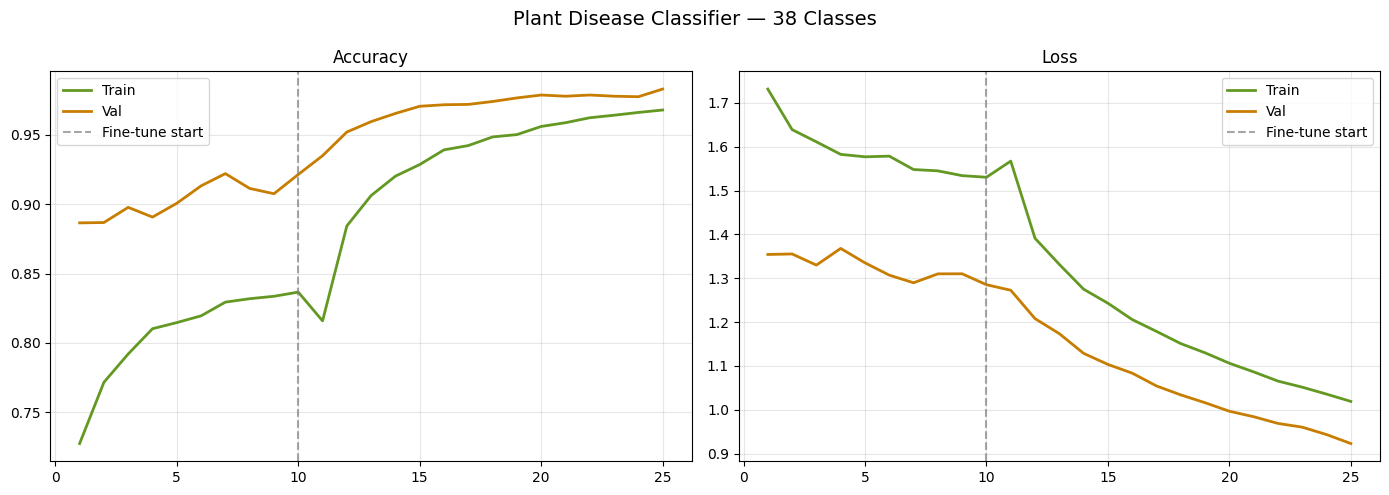

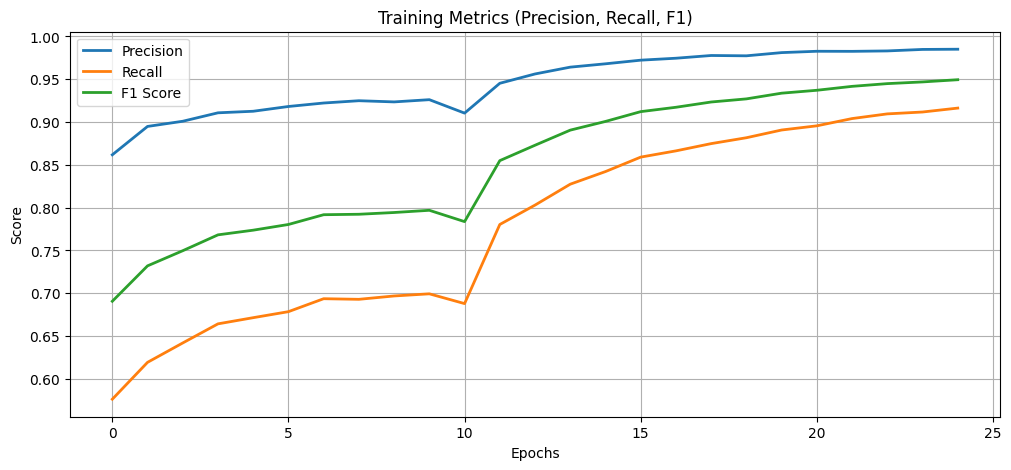

In [ ]:
# ── CELL 10 ────────────────────────────────────────────────────────
def plot_curves(h1, h2):
    acc  = h1.history['accuracy']    + h2.history['accuracy']
    vacc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss']        + h2.history['loss']
    vloss= h1.history['val_loss']    + h2.history['val_loss']
    ep   = range(1, len(acc)+1)
    split= len(h1.history['accuracy'])

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Plant Disease Classifier — 38 Classes', fontsize=14)
    for ax, y, yv, title in zip(
            [a1,a2],[acc,loss],[vacc,vloss],['Accuracy','Loss']):
        ax.plot(ep, y,  label='Train', color='#639922', linewidth=2)
        ax.plot(ep, yv, label='Val',   color='#C77D00', linewidth=2)
        ax.axvline(split, color='gray', linestyle='--',
                   label='Fine-tune start', alpha=0.7)
        ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_curves(history1, history2)
def plot_extra_metrics(h1, h2):
    precision = h1.history.get('precision', []) + h2.history.get('precision', [])
    recall    = h1.history.get('recall', []) + h2.history.get('recall', [])

    if len(precision) == 0 or len(recall) == 0:
        print("⚠️ Precision/Recall not found in history. Check model.compile()")
        return

    # F1 calculation
    f1 = [2*(p*r)/(p+r+1e-8) for p, r in zip(precision, recall)]

    plt.figure(figsize=(12,5))
    plt.plot(precision, label='Precision', linewidth=2)
    plt.plot(recall, label='Recall', linewidth=2)
    plt.plot(f1, label='F1 Score', linewidth=2)

    plt.title("Training Metrics (Precision, Recall, F1)")
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.legend()
    plt.grid()
    plt.show()

plot_extra_metrics(history1, history2)

In [ ]:
# ── CELL 11 ────────────────────────────────────────────────────────
model.load_weights('/content/drive/MyDrive/best_final.h5')

results = model.evaluate(test_gen, verbose=1)

loss = results[0]
acc = results[1]   # accuracy is always second

print(f"\n{'='*45}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  Test Loss     : {loss:.4f}")
print(f"{'='*45}")
print(f"\n{'='*45}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  Test Loss     : {loss:.4f}")
print(f"{'='*45}")

y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes

print("\n--- Per-Class Report (all 38 classes) ---")
print(classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, digits=4))
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert predictions
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Overall metrics
test_acc = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, average='weighted')
test_rec = recall_score(y_true, y_pred, average='weighted')
test_f1 = f1_score(y_true, y_pred, average='weighted')

print("\n" + "="*50)
print("📊 FINAL TEST METRICS")
print("="*50)
print(f"Accuracy  : {test_acc*100:.2f}%")
print(f"Precision : {test_prec*100:.2f}%")
print(f"Recall    : {test_rec*100:.2f}%")
print(f"F1 Score  : {test_f1*100:.2f}%")
print("="*50)

341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.9855 - loss: 0.9214 - precision: 0.9902 - recall: 0.9768

  Test Accuracy : 98.55%
  Test Loss     : 0.9214

  Test Accuracy : 98.55%
  Test Loss     : 0.9214
341/341 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step

--- Per-Class Report (all 38 classes) ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000        95
                                 Apple___Black_rot     0.9792    1.0000    0.9895        94
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        42
                                   Apple___healthy     0.9919    0.9879    0.9899       248
                               Blueberry___healthy     1.0000    1.0000    1.0000       226
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9874    0.9937       159
                 Cherry_(including_sour)___healthy   

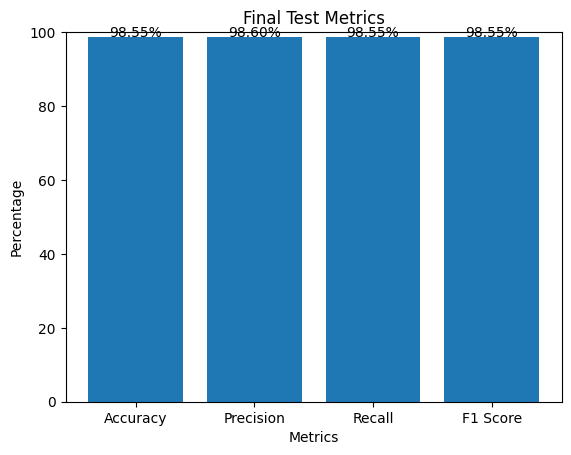

In [ ]:
import matplotlib.pyplot as plt

# Your values
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [98.55, 98.60, 98.55, 98.55]

# Create plot
plt.figure()
plt.bar(metrics, values)

# Labels & title
plt.xlabel("Metrics")
plt.ylabel("Percentage")
plt.title("Final Test Metrics")

# Add value labels on top
for i, v in enumerate(values):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center')

plt.ylim(0, 100)
plt.show()

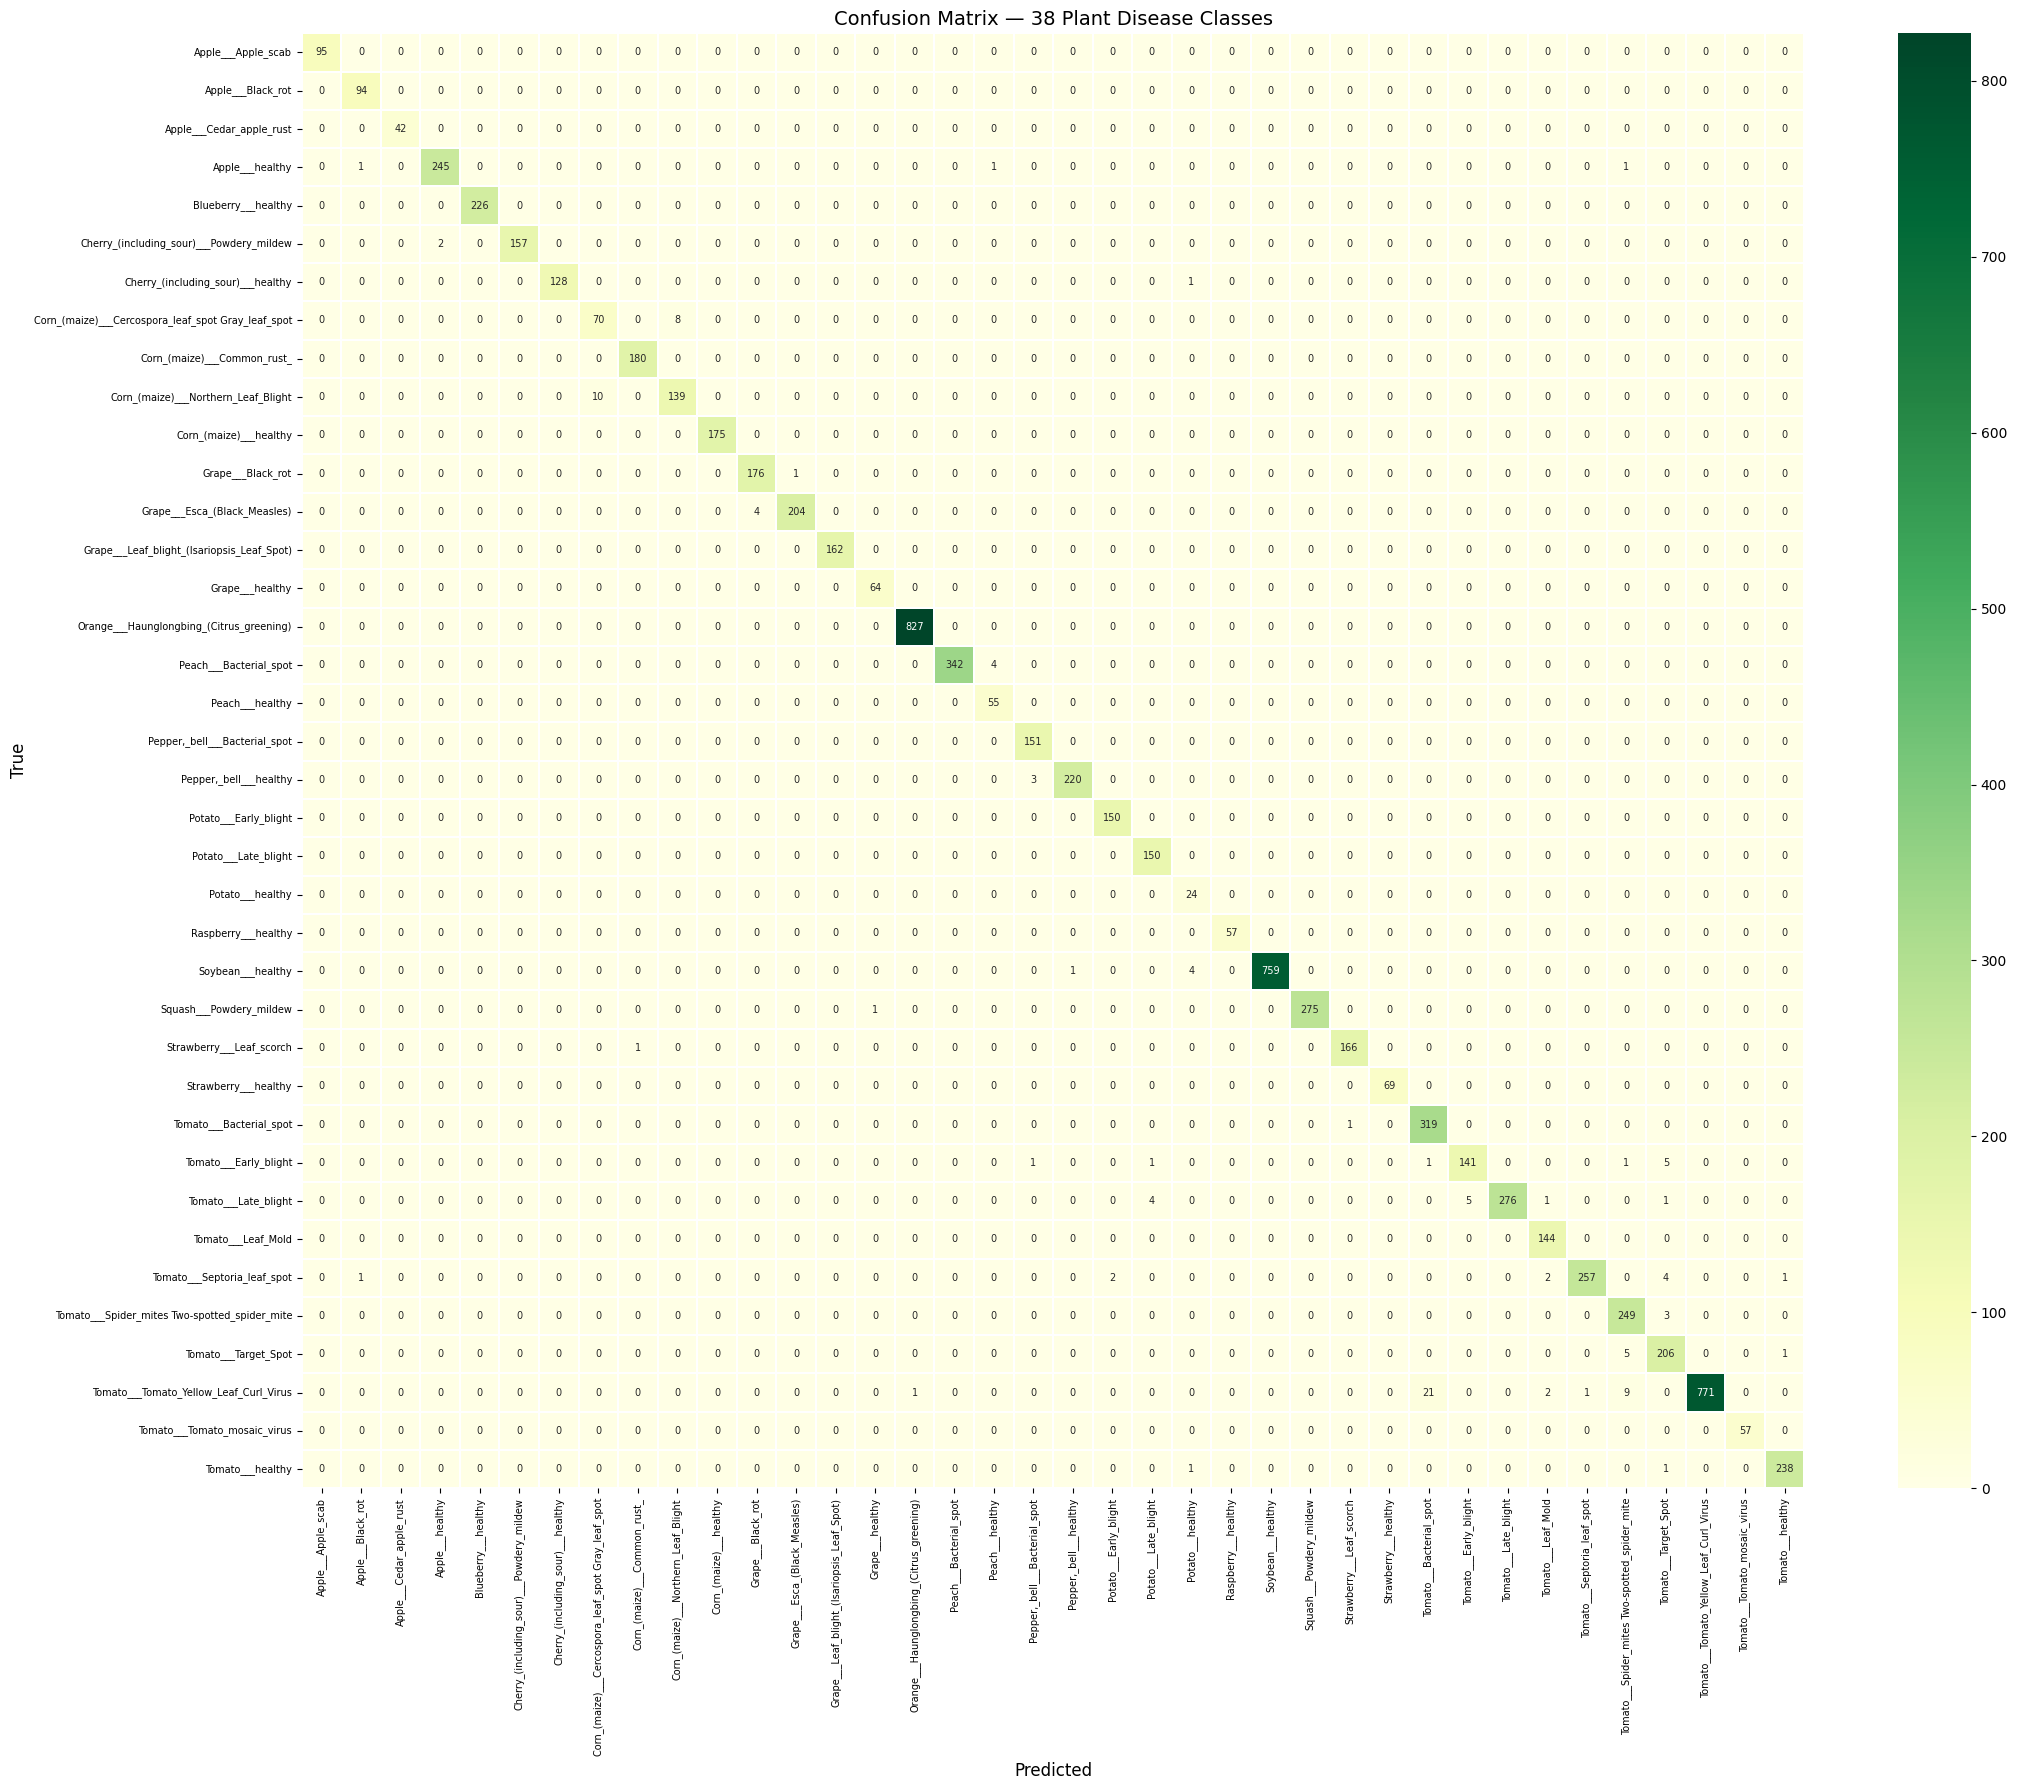

In [ ]:
# ── CELL 12 ────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.3, annot_kws={'size':7})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — 38 Plant Disease Classes', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout(); plt.show()

In [ ]:
# ── CELL 13 ────────────────────────────────────────────────────────
def smart_predict(img_path, model, class_names,
                   threshold=THRESHOLD, n_aug=10):

    from PIL import Image
    import numpy as np
    import matplotlib.pyplot as plt
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from tensorflow.keras.applications.efficientnet import preprocess_input

    # Load image
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    arr = np.array(img_resized, dtype=np.float32)
    arr_4d = np.expand_dims(arr, axis=0)

    # TTA generator
    tta_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        horizontal_flip=True,
        vertical_flip=True,
        zoom_range=0.1,
        brightness_range=[0.85, 1.15]
    )

    preds_list = []

    # Original prediction
    orig = preprocess_input(arr_4d.copy())
    preds_list.append(model.predict(orig, verbose=0)[0])

    # Augmented predictions
    for batch in tta_gen.flow(arr_4d, batch_size=1, seed=SEED):
        preds_list.append(model.predict(batch, verbose=0)[0])
        if len(preds_list) >= n_aug:
            break

    mean_pred = np.mean(preds_list, axis=0)
    top_conf  = float(np.max(mean_pred))
    top_idx   = int(np.argmax(mean_pred))
    top3      = np.argsort(mean_pred)[-3:][::-1]

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Show image
    ax1.imshow(img_resized)
    ax1.axis('off')

    if top_conf < threshold:
        ax1.set_title(
            f"❌ NOT a known plant leaf\nConfidence: {top_conf*100:.1f}%",
            color='red', fontsize=11
        )
    else:
        ax1.set_title(
            f"✅ {class_names[top_idx]}\nConfidence: {top_conf*100:.1f}%",
            color='darkgreen', fontsize=11
        )

    # ===== FIXED BAR CHART =====
    top5 = np.argsort(mean_pred)[-5:][::-1]

    labels_5 = [
        class_names[i].replace('___', ' - ').replace('_', ' ')
        for i in top5
    ]

    vals_5 = [mean_pred[i]*100 for i in top5]

    colors = ['#639922'] + ['#C0DD97'] * 4

    y_pos = np.arange(len(labels_5))
    ax2.barh(y_pos, vals_5, color=colors)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels_5, fontsize=9)

    ax2.invert_yaxis()
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title('Top 5 Predictions')

    ax2.axvline(60, color='red', linestyle='--', alpha=0.5, label='threshold')
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Console output
    print(f"\nResult: {class_names[top_idx] if top_conf >= threshold else 'REJECTED'}")
    print(f"TTA confidence: {top_conf*100:.2f}%")

    print("\nTop-3 predictions:")
    for i in top3:
        bar = '█' * int(mean_pred[i]*40)
        print(f"  {class_names[i]:<40s} {bar} {mean_pred[i]*100:.2f}%")

print("smart_predict() ready ✓")
print("Usage: smart_predict('your_image.jpg', model, CLASS_NAMES)")

smart_predict() ready ✓
Usage: smart_predict('your_image.jpg', model, CLASS_NAMES)


Saving WhatsApp Image 2026-04-23 at 12.38.58 PM.jpeg to WhatsApp Image 2026-04-23 at 12.38.58 PM.jpeg


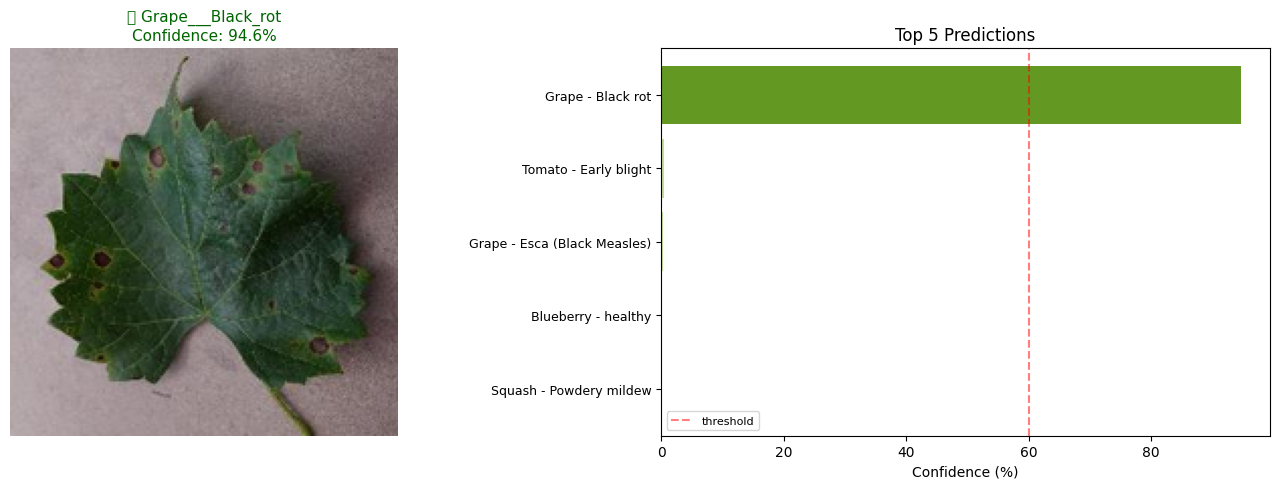


Result: Grape___Black_rot
TTA confidence: 94.58%

Top-3 predictions:
  Grape___Black_rot                        █████████████████████████████████████ 94.58%
  Tomato___Early_blight                     0.54%
  Grape___Esca_(Black_Measles)              0.35%


In [ ]:
# ── CELL 14 ────────────────────────────────────────────────────────
# Upload any leaf photo and predict
# Works with: tomato, apple, corn, grape, potato, pepper,
#             cherry, peach, strawberry, orange, blueberry,
#             soybean, squash, raspberry leaves ONLY

from google.colab import files
up = files.upload()
img_path = list(up.keys())[0]

smart_predict(img_path, model, CLASS_NAMES, threshold=THRESHOLD)

In [ ]:
# ── CELL 15 ────────────────────────────────────────────────────────
model.save('plant_disease_38class.h5')

with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

with open('config.json', 'w') as f:
    json.dump({'img_size': IMG_SIZE,
               'num_classes': NUM_CLASSES,
               'threshold': THRESHOLD,
               'model': 'EfficientNetB3',
               'preprocessing': 'preprocess_input'}, f, indent=2)

print("Saved:")
print("  plant_disease_38class.h5")
print("  class_names.json")
print("  config.json")

from google.colab import files
files.download('plant_disease_38class.h5')
files.download('class_names.json')
files.download('config.json')

Saved:
  plant_disease_38class.h5
  class_names.json
  config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>